# Sieci Neuronowe i algorytmy genetyczne - projekt 2026
Temat: Linear Klasyfikacja danych z biblioteką Keras (TensorFlow)

Wybrane zagadnienie: Linear Neural Networks for Regression

Autorzy:
Grzegorz Potocki, Tomasz Majchrzak

## Wprowadzenie

Niniejszy projekt został opracowany w celu realizacji klasyfikacji obrazów z datasetu `fashion_minst` zintegrowanego z biblioteką `keras`. Kluczowymi krokami niezbędnymi do poprawnego przeporowadzenia treningu sieci neuronoej (w tym wypadku zgodnie z wybranym zagadnieniem jest to liniowa sieć neuronowa) oraz oceny rezultatów jest odpowiednia analiza eksploracyjna EDA (ang. Exploratory Data Analysis) oraz etap preprocessingu danych.

Wybranym datasetem jest właśnie `fashion_minst`, który zawiera łącznie 70 000 obrazów różnych ubrań i akcesoriów przeznaczonych do przeprowadzenia klasyfikacji.

Do wczytania oraz eksploracyjnej analizy danych zostaną wykorzystane takie moduły jak `numpy`, `pandas`, `seaborn`, `matplotlib` oraz poźniej `pillow` w celu zapisania błędnych klasyfikacji do odpowiednich folderów. Głównymi narzędziami potrzebnymi do zbudowania, treningu oraz testowania sieci neuronowych będą moduły `tensorflow` oraz `keras`. 

Projekt skupia się na porównianiu wydajności ze względu na zmianę konkretnych parametrów liniowej sieci neuronowej oraz nieliniowej DNN (ang. Deep Neural Network) z warstwami ukrytmi.  

## Konfiguracja środowiska

Pierwszym obowiązkowym krokiem w procesie budowania i ewaluacji sieci neuronowych jest poprawna konfiguracja środowiska, w którym będzie się pracować. W tym celu za pomocą modułu `os` zostały wyłączone potencjalne fałszywe komunikaty związane z błędami instalacji modułu `keras` oraz `tensorflow` na systemie linux. Ponad to zaimplementowano małą poprawkę do modułu `numpy` - wyświetlanie liczb zmiennoprzecinkowy z prezycją tylko do trzech liczb po przecinku oraz wyłączenie notacji naukowej dla małych liczb.

In [19]:
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image


np.set_printoptions(precision=3, suppress=True)

In [20]:
import tensorflow as tf
import keras
from keras import layers

In [21]:
import tensorflow as tf
print("Czy TF widzi GPU?:", tf.config.list_physical_devices('GPU'))
print("Urządzenie logowania operacji:", tf.debugging.get_log_device_placement())

Czy TF widzi GPU?: []
Urządzenie logowania operacji: False


W tym miejscu w ramach utrzymania przejrzystości kodu zostają wyświetlone użyte wersje modułów `tensorflow` oraz `keras`.

In [22]:
print(tf.__version__, keras.__version__)

2.21.0 3.14.1


Zgodnie z przyjętą konwecją podczas pracy z sieciami neuronowymi zostały również zdefiniowane wartości `set_seed` dla `tensorflow` oraz `seed` dla `numpy` w ramach powtarzalności wyników.

In [23]:
tf.random.set_seed(42)
np.random.seed(42)

## Eksploracyjna analiza danych (EDA)

Ze względu na to, że dataset jest już zintegorwany z modułem `keras` wystarczy tylko go załadować do odpowiednich zmiennych. Dane zawarte w tym module zostały w łatwy sposób można posortować na treningowe i testowe oraz nie wymagają żadnego potencjalnego pozbywania sie wartości `NaN` jak to mogłoby się przydarzyć w zewnętrznych datasetach.

In [24]:
# Ładowanie zbioru danych
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

# Definicje nazw klas
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Po załadowaniu danych warto sprawdzić jaki kształt mają teraz poszczególne zmienne.

In [25]:
# Kształty zbiorów treningowych
print("Zbiór treningowy - obrazy:", train_images.shape)
print("Zbiór treningowy - etykiety:", train_labels.shape)
print("Zbiór testowy - obrazy:", test_images.shape)
print("Zbiór testowy - etykiety:", test_labels.shape)

Zbiór treningowy - obrazy: (60000, 28, 28)
Zbiór treningowy - etykiety: (60000,)
Zbiór testowy - obrazy: (10000, 28, 28)
Zbiór testowy - etykiety: (10000,)


Pomimo faktu, że dane są prawie odrazu gotowe do pracy z sieciami neuronowymi to i tak trzeba je poddac normalizcji. Zanim jednak się do tego przejdzie, należy sprawdzić jaki typ oraz jakie sa oryginalne wartości, aby późniejsza normalizacjia była przeporwadzona w dobry sposób.

In [26]:
# Typ i zakres wartości przed normalizacją
print("Typ danych:", train_images.dtype)
print("Min wartość piksela:", train_images.min())
print("Max wartość piksela:", train_images.max())

Typ danych: uint8
Min wartość piksela: 0
Max wartość piksela: 255


Równie istotna sprawą oprócz samego zakresu wartości danych jest poznanie ich rozkładu. 

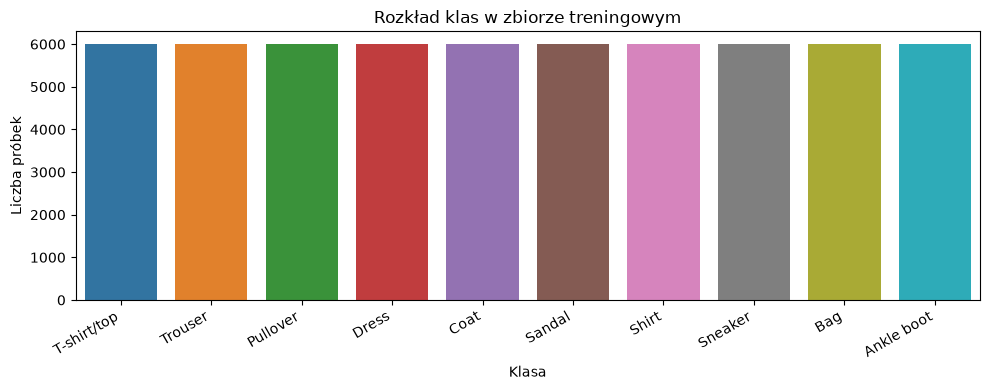

T-shirt/top: 6000 próbek
Trouser: 6000 próbek
Pullover: 6000 próbek
Dress: 6000 próbek
Coat: 6000 próbek
Sandal: 6000 próbek
Shirt: 6000 próbek
Sneaker: 6000 próbek
Bag: 6000 próbek
Ankle boot: 6000 próbek


In [27]:
unique, counts = np.unique(train_labels, return_counts=True)

class_labels = [class_names[i] for i in unique]

plt.figure(figsize=(10, 4))
sns.barplot(x=class_labels, y=counts, hue=class_labels, legend=False)
plt.title("Rozkład klas w zbiorze treningowym")
plt.xlabel("Klasa")
plt.ylabel("Liczba próbek")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

for name, count in zip(class_labels, counts):
    print(f"{name}: {count} próbek")

W tym miejscu juz wszystkie najważniejsze informacje z perspektwy budowania sieci neuronowych są juz wyświetlone, ale w ramach dodatkowej wizalizacji można wyświetlich po jednej przykładowej próbce z każdej klasy.

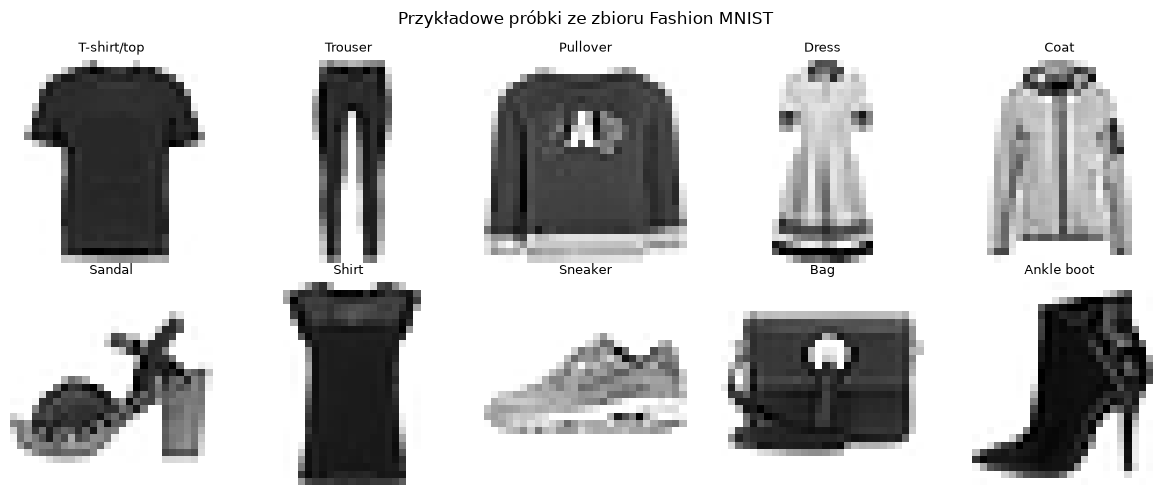

In [28]:
# Wizualna analiza zbioru danych
# Po jednej próbce z każdej z 10 klas
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Przykładowe próbki ze zbioru Fashion MNIST")

for i, ax in enumerate(axes.flat):
    idx = np.random.choice(np.where(train_labels == i)[0])
    ax.imshow(train_images[idx], cmap="binary")
    ax.set_title(class_names[i], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Preprocessing i podział danych

Ze względu na to że, załadowny dataset w zasadzie jest gotowy do pracy jedyną rzeczą, która jest wymagana to znormalizowanie wartości pikseli.

In [29]:
# Normalizacja wartości pikseli
train_images_normalized = train_images / 255.0
test_images_normalized = test_images / 255.0

In [30]:
# Zakres wartości po normalizacji
print("Min wartość piksela:", train_images_normalized.min())
print("Max wartość piksela:", train_images_normalized.max())

Min wartość piksela: 0.0
Max wartość piksela: 1.0


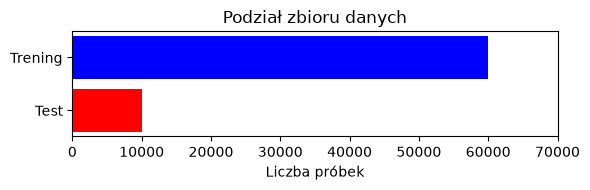

In [31]:
# Podział zbioru danych
plt.figure(figsize=(6, 2))
bars = plt.barh(["Test", "Trening"], [10000, 60000], color=["red", "blue"])
plt.xlabel("Liczba próbek")
plt.xlim(0, 70000)
plt.title("Podział zbioru danych")
plt.tight_layout()
plt.show()

## Budowa i trening modeli oraz ich ewaluacja

W tym miejscu zostaną przeprowadzone testy na liniowej sieci. W tym celu zostały zdefiniowane nastepujące funkcje:

- `build_linear_model()` - funkcja budująca prosty model liniowy za pomocą `keras_Sequential()`. Obraz jest spłaszczany do pojedynczego wektora, a warstwa wyjściowa przypisuje prawdopodobieństwo każdej z klas. 
- `plot_history()` - funkcja odpowiedzialna za wyświetlanie dwóch wykresów - pierwszy przedstawia jak zmienia się wartość wskaźnika accuracy względem postępująch epok, a drugi to charakterystyka wartości funkcji błędu względem epok
- `build_dnn_model()` - budowanie głębokiej sieci neuronowej z dwoma warstwami głebokimi, aktywowanymi za pomocą funkcji `relu`
- `run_experiment()` - funkcja pomocnicza, zbierająca w całość całą procedurę testową

In [32]:
all_results = []

In [33]:
# Model liniowy: Flatten spłaszcza obraz 28x28 do wektora 784 pikseli
# Warstwa Dense(10, softmax) przypisuje prawdopodobieństwo każdej z 10 klas
def build_linear_model(lr):
    model = keras.Sequential([
        keras.Input(shape=(28,28)),
        layers.Flatten(),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [34]:
# Krzywe uczenia - dokładność na zbiorze treningowym
# i walidacyjnym w funkcji epoki
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title)

    # Krzywa accuracy
    axes[0].plot(history.history["accuracy"],     label="trening")
    axes[0].plot(history.history["val_accuracy"], label="walidacja")
    axes[0].set_xlabel("Epoka")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_ylim([0, 1])
    axes[0].legend()
    axes[0].grid(True)

    # Krzywa loss
    axes[1].plot(history.history["loss"],     label="trening")
    axes[1].plot(history.history["val_loss"], label="walidacja")
    axes[1].set_xlabel("Epoka")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [35]:
def run_experiment(build_fn, model_name, lr, epochs, results, save_errors=True, show_summary="False"):
    model = build_fn(lr)
    
    if show_summary:
        model.summary()
    
    history = model.fit(
        train_images_normalized, train_labels,
        epochs=epochs,
        validation_split=0.1,
        verbose=1
    )

    _, acc = model.evaluate(test_images_normalized, test_labels, verbose=0)
    plot_history(history, title=f"{model_name} | epochs={epochs} | lr={lr} | acc={acc:.3f}")

    y_pred_proba = model.predict(test_images_normalized, verbose=1)
    y_pred = np.argmax(y_pred_proba, axis=1)

    if save_errors:
        folder = f"wrong_predictions/{model_name}_epochs={epochs}_lr={lr}"
        os.makedirs(folder, exist_ok=True)
        wrong_idx = np.where(y_pred != test_labels)[0]
        for idx in wrong_idx:
            img = Image.fromarray((test_images_normalized[idx] * 255).astype(np.uint8))
            true = class_names[test_labels[idx]].replace("/", "-")
            pred = class_names[y_pred[idx]].replace("/", "-")
            conf = y_pred_proba[idx, y_pred[idx]]
            img.save(f"{folder}/{idx}_true={true}_pred={pred}_conf={conf:.2f}.png")
        print(f"Zapisano {len(wrong_idx)} błędów -> {folder}/")

    results.append({"Model": model_name, "Epochs": epochs, "Learning rate": lr, "Accuracy": acc})

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 955us/step - accuracy: 0.7934 - loss: 0.6122 - val_accuracy: 0.8283 - val_loss: 0.4922
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 903us/step - accuracy: 0.8406 - loss: 0.4679 - val_accuracy: 0.8387 - val_loss: 0.4586
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8487 - loss: 0.4406 - val_accuracy: 0.8422 - val_loss: 0.4449
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 754us/step - accuracy: 0.8524 - loss: 0.4260 - val_accuracy: 0.8452 - val_loss: 0.4370
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 745us/step - accuracy: 0.8559 - loss: 0.4166 - val_accuracy: 0.8485 - val_loss: 0.4318
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 750us/step - accuracy: 0.8582 - loss: 0.4097 - val_accuracy: 0.8493 - val_loss: 0.4281
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 780us/step - accuracy: 0.8604 - loss: 0.4044 - val_accuracy: 0.8503 - val_loss: 0.4254
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 688us/step - accuracy: 0.8616 - l

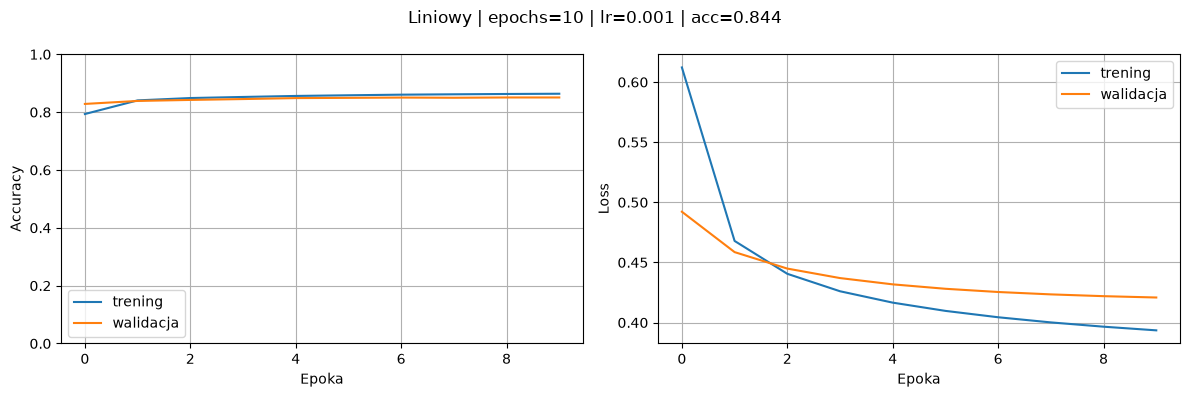

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 392us/step
Zapisano 1565 błędów -> wrong_predictions/Liniowy_epochs=10_lr=0.001/
Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 806us/step - accuracy: 0.7926 - loss: 0.6114 - val_accuracy: 0.8260 - val_loss: 0.4932
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 701us/step - accuracy: 0.8405 - loss: 0.4676 - val_accuracy: 0.8392 - val_loss: 0.4595
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 718us/step - accuracy: 0.8492 - loss: 0.4404 - val_accuracy: 0.8422 - val_loss: 0.4457
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 673us/step - accuracy: 0.8524 - loss: 0.4259 - val_accuracy: 0.8447 - val_loss: 0.4377
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step - accuracy: 0.8559 - loss: 0.4165 - val_accuracy: 0.8468 - val_loss: 0.4324
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 666us/step - accuracy: 0.8583 - loss: 0.4096 - val_accuracy: 0.8478 - val_loss: 0.4287
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 754us/step - accuracy: 0.8599 - loss: 0.4043 - val

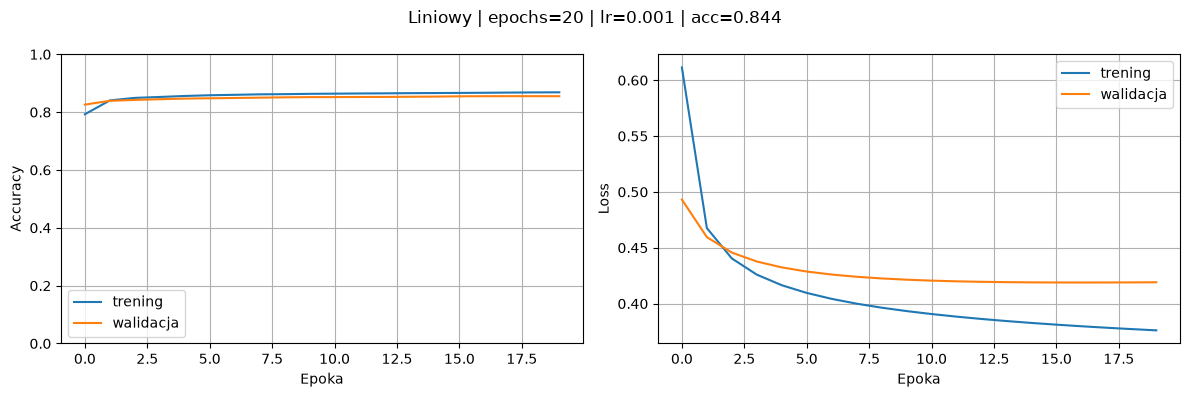

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 392us/step
Zapisano 1558 błędów -> wrong_predictions/Liniowy_epochs=20_lr=0.001/
Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 895us/step - accuracy: 0.7963 - loss: 0.6076 - val_accuracy: 0.8260 - val_loss: 0.4922
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 664us/step - accuracy: 0.8408 - loss: 0.4674 - val_accuracy: 0.8397 - val_loss: 0.4590
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 670us/step - accuracy: 0.8495 - loss: 0.4405 - val_accuracy: 0.8442 - val_loss: 0.4452
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 678us/step - accuracy: 0.8538 - loss: 0.4260 - val_accuracy: 0.8470 - val_loss: 0.4372
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 701us/step - accuracy: 0.8566 - loss: 0.4166 - val_accuracy: 0.8482 - val_loss: 0.4319
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 688us/step - accuracy: 0.8588 - loss: 0.4097 - val_accuracy: 0.8487 - val_loss: 0.4282
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 696us/step - accuracy: 0.8604 - loss: 0.4044 - val

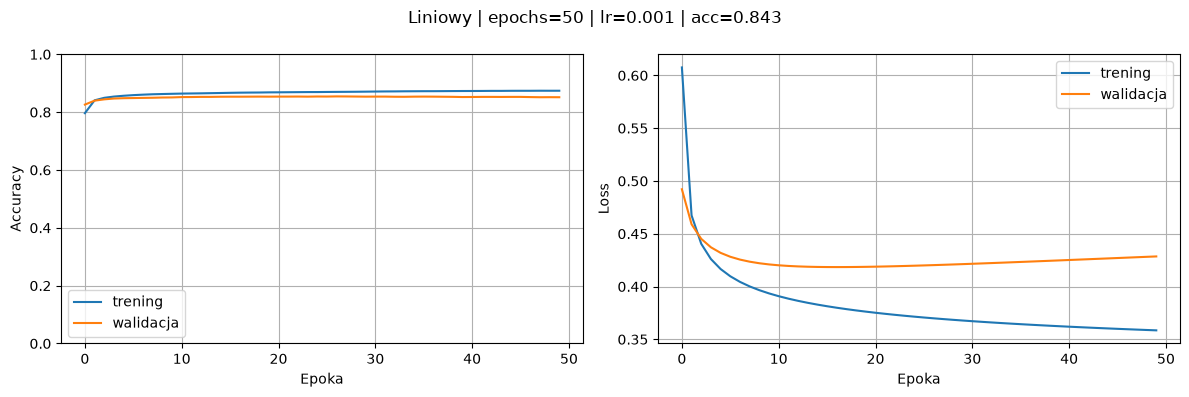

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 395us/step
Zapisano 1571 błędów -> wrong_predictions/Liniowy_epochs=50_lr=0.001/


In [36]:
# Model liniowy - wpływ liczby epok
for i, epochs in enumerate([10, 20, 50]):
    run_experiment(build_linear_model,
                   "Liniowy",
                   lr=0.001,
                   epochs=epochs,
                   results=all_results,
                   show_summary=(i == 0))

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 785us/step - accuracy: 0.8014 - loss: 0.6210 - val_accuracy: 0.8450 - val_loss: 0.4905
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 723us/step - accuracy: 0.8245 - loss: 0.5753 - val_accuracy: 0.8457 - val_loss: 0.4935
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 667us/step - accuracy: 0.8288 - loss: 0.5670 - val_accuracy: 0.8440 - val_loss: 0.5091
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 673us/step - accuracy: 0.8326 - loss: 0.5598 - val_accuracy: 0.8428 - val_loss: 0.5235
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 683us/step - accuracy: 0.8343 - loss: 0.5548 - val_accuracy: 0.8403 - val_loss: 0.5374
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 685us/step - accuracy: 0.8360 - loss: 0.5519 - val_accuracy: 0.8402 - val_loss: 0.5538
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 667us/step - accuracy: 0.8363 - loss: 0.5499 - val_accuracy: 0.8387 - val_loss: 0.5609
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 682us/step - accuracy: 0.8385 -

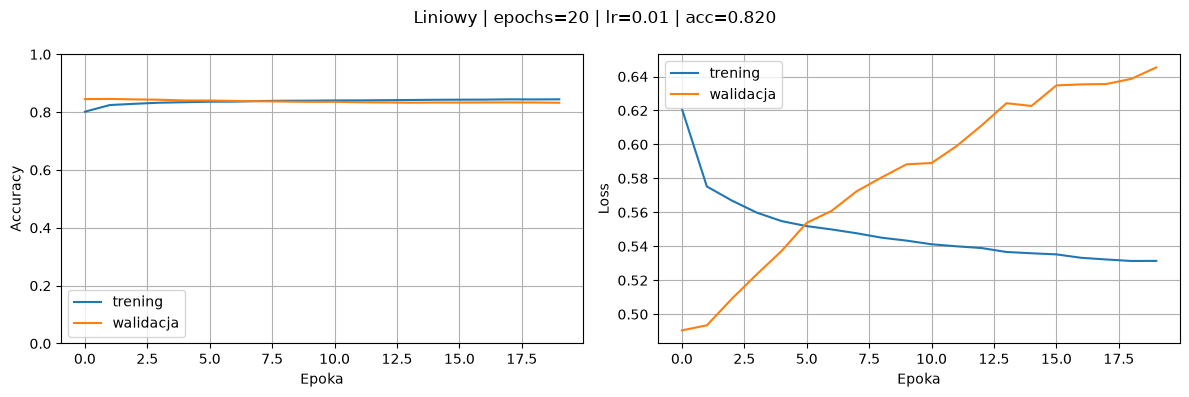

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 408us/step
Zapisano 1799 błędów -> wrong_predictions/Liniowy_epochs=20_lr=0.01/


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - accuracy: 0.7914 - loss: 0.6152 - val_accuracy: 0.8243 - val_loss: 0.4941
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 750us/step - accuracy: 0.8394 - loss: 0.4690 - val_accuracy: 0.8395 - val_loss: 0.4593
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 681us/step - accuracy: 0.8489 - loss: 0.4412 - val_accuracy: 0.8432 - val_loss: 0.4449
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 698us/step - accuracy: 0.8529 - loss: 0.4265 - val_accuracy: 0.8455 - val_loss: 0.4367
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 671us/step - accuracy: 0.8560 - loss: 0.4169 - val_accuracy: 0.8467 - val_loss: 0.4314
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 679us/step - accuracy: 0.8583 - loss: 0.4099 - val_accuracy: 0.8482 - val_loss: 0.4276
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 698us/step - accuracy: 0.8600 - loss: 0.4045 - val_accuracy: 0.8487 - val_loss: 0.4249
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 688us/step - accuracy: 0.8614 -

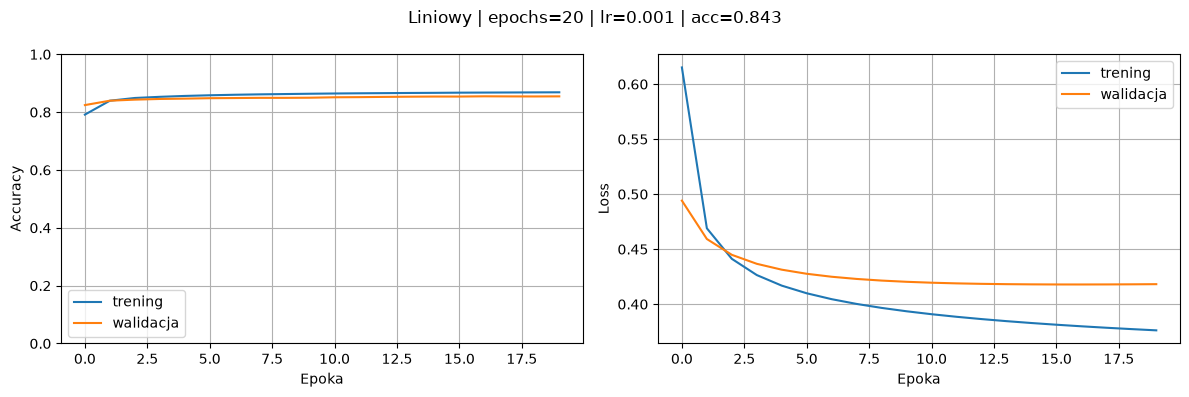

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 401us/step
Zapisano 1568 błędów -> wrong_predictions/Liniowy_epochs=20_lr=0.001/


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 824us/step - accuracy: 0.6415 - loss: 1.0996 - val_accuracy: 0.7490 - val_loss: 0.7408
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 737us/step - accuracy: 0.7730 - loss: 0.6840 - val_accuracy: 0.7918 - val_loss: 0.6155
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 717us/step - accuracy: 0.8022 - loss: 0.5983 - val_accuracy: 0.8115 - val_loss: 0.5613
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 710us/step - accuracy: 0.8154 - loss: 0.5545 - val_accuracy: 0.8202 - val_loss: 0.5301
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 681us/step - accuracy: 0.8237 - loss: 0.5273 - val_accuracy: 0.8263 - val_loss: 0.5095
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 692us/step - accuracy: 0.8305 - loss: 0.5083 - val_accuracy: 0.8323 - val_loss: 0.4947
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 695us/step - accuracy: 0.8351 - loss: 0.4942 - val_accuracy: 0.8360 - val_loss: 0.4834
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 683us/step - accuracy: 0.8385 -

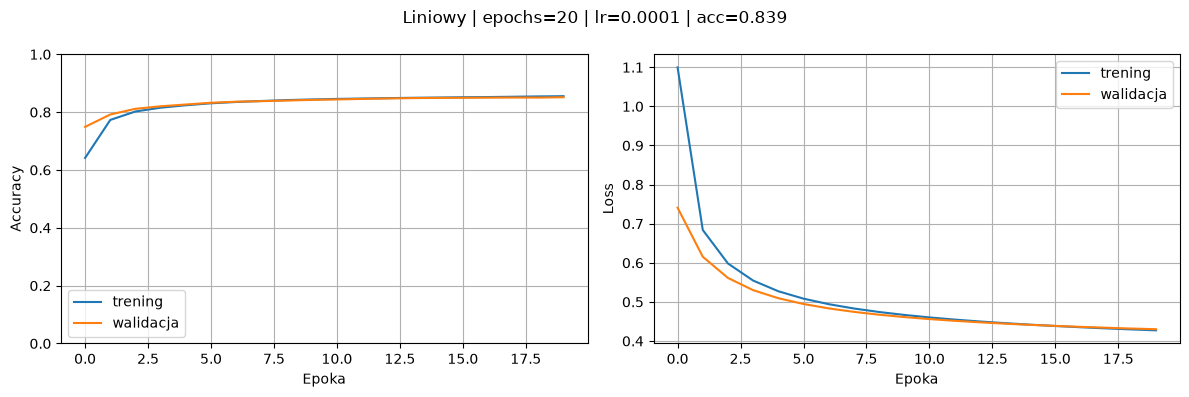

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 381us/step
Zapisano 1606 błędów -> wrong_predictions/Liniowy_epochs=20_lr=0.0001/


In [37]:
# Model liniowy — wpływ learning rate
for lr in [0.01, 0.001, 0.0001]:
    run_experiment(build_linear_model, "Liniowy", lr=lr, epochs=20, results=all_results)

## Eksperyment z siecią nieliniową (porównanie)

Następnym etapem ewaluacji zbudowanych liniowych sieci neuronowych jest porównanie ich do przykładowej sieci nieliniowej z dwiema warstwami ukrytymi, aktywowanymi za pomoca funkcji `relu` w ramach wprowadzenia nieliniowości. 

In [38]:
# Model nieliniowy z dwiema ukrytymi warstwami ReLU - punkt odniesienia
# Dwie warstwy Dense(128) i Dense(64) z aktywacją ReLU
# wprowadzają nieliniowość, której model liniowy nie posiada
def build_dnn_model(lr):
    model = keras.Sequential([
        keras.Input(shape=(28,28)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8048 - loss: 0.5427 - val_accuracy: 0.8363 - val_loss: 0.4865
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8420 - loss: 0.4430 - val_accuracy: 0.8337 - val_loss: 0.4697
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8504 - loss: 0.4232 - val_accuracy: 0.8458 - val_loss: 0.4308
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8553 - loss: 0.4093 - val_accuracy: 0.8528 - val_loss: 0.4221
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8593 - loss: 0.3985 - val_accuracy: 0.8492 - val_loss: 0.4380
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8627 - loss: 0.3888 - val_accuracy: 0.8572 - val_loss: 0.4191
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8629 - loss: 0.3843 - val_accuracy: 0.8435 - val_loss: 0.4575
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8618 - loss: 0.3873 - 

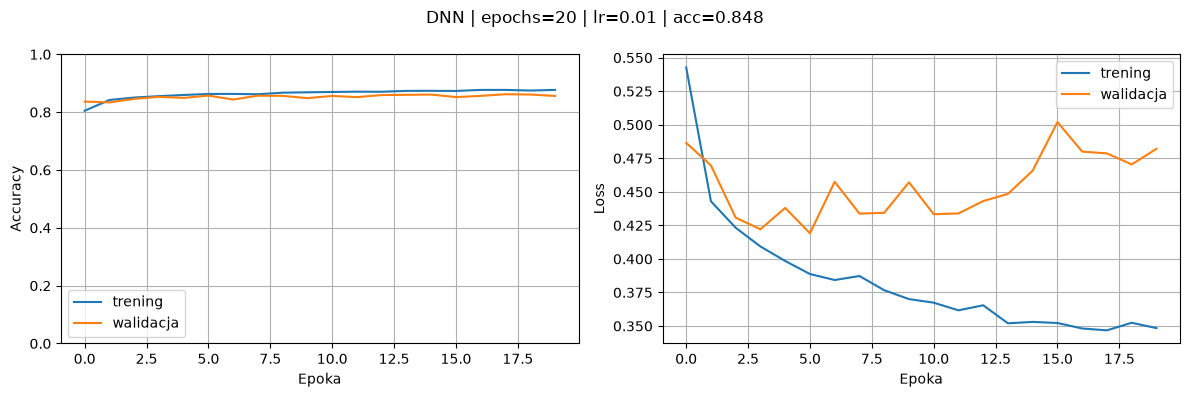

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step
Zapisano 1525 błędów -> wrong_predictions/DNN_epochs=20_lr=0.01/


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8170 - loss: 0.5111 - val_accuracy: 0.8525 - val_loss: 0.4073
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8643 - loss: 0.3749 - val_accuracy: 0.8567 - val_loss: 0.3837
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8752 - loss: 0.3377 - val_accuracy: 0.8612 - val_loss: 0.3780
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8842 - loss: 0.3119 - val_accuracy: 0.8672 - val_loss: 0.3648
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8912 - loss: 0.2928 - val_accuracy: 0.8690 - val_loss: 0.3583
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8960 - loss: 0.2779 - val_accuracy: 0.8732 - val_loss: 0.3537
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9008 - loss: 0.2640 - val_accuracy: 0.8762 - val_loss: 0.3497
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9065 - loss: 0.2501 - 

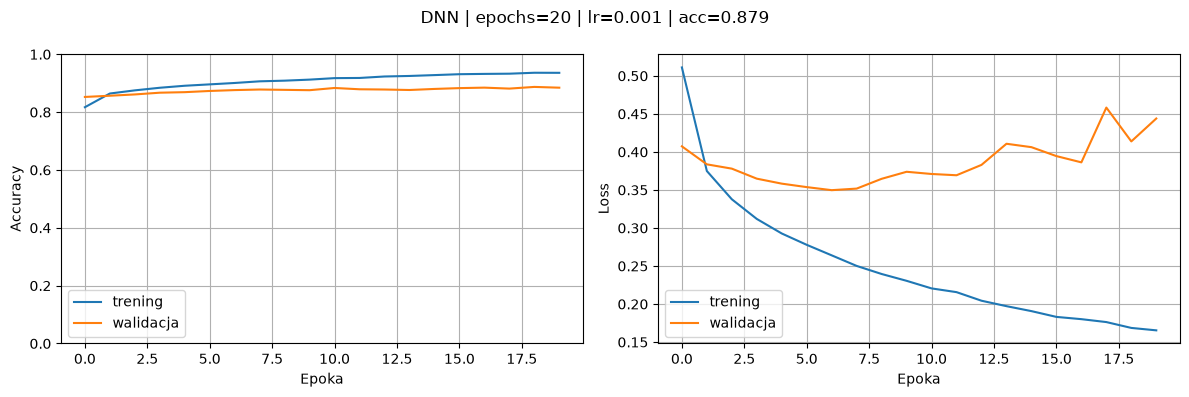

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 498us/step
Zapisano 1206 błędów -> wrong_predictions/DNN_epochs=20_lr=0.001/


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7763 - loss: 0.6950 - val_accuracy: 0.8282 - val_loss: 0.4881
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8456 - loss: 0.4474 - val_accuracy: 0.8437 - val_loss: 0.4320
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8599 - loss: 0.4043 - val_accuracy: 0.8553 - val_loss: 0.4030
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8681 - loss: 0.3787 - val_accuracy: 0.8593 - val_loss: 0.3865
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8740 - loss: 0.3603 - val_accuracy: 0.8635 - val_loss: 0.3737
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8784 - loss: 0.3458 - val_accuracy: 0.8688 - val_loss: 0.3650
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8822 - loss: 0.3336 - val_accuracy: 0.8690 - val_loss: 0.3576
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8856 - loss: 0.3231 - 

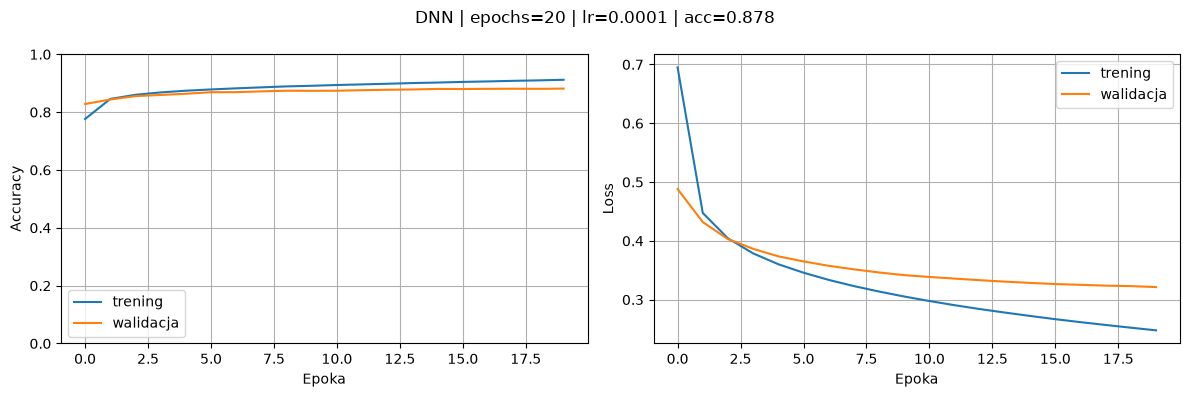

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 515us/step
Zapisano 1217 błędów -> wrong_predictions/DNN_epochs=20_lr=0.0001/


In [39]:
# DNN — wpływ learning rate
for lr in [0.01, 0.001, 0.0001]:
    run_experiment(build_dnn_model, "DNN", lr=lr, epochs=20, results=all_results)

## Analiza wyników klasyfikacji

Rezultaty zebrane z przeprowadzonych eksperymentów zostały skondensowane do jednej tabeli, gdzie modele posortowano ze względu na wartość wskaźnika accuracy (prezycja). Ponad to, duplikaty zostały usunięte.

In [40]:
summary = pd.DataFrame(all_results)
summary = summary.drop_duplicates(subset=["Model", "Epochs", "Learning rate"])
summary = summary.sort_values("Accuracy", ascending=False).reset_index(drop=True)
summary

,Model,Epochs,Learning rate,Accuracy
0,DNN,20,0.0010,0.8794
1,DNN,20,0.0001,0.8783
2,DNN,20,0.0100,0.8475
3,Liniowy,20,0.0010,0.8442
4,Liniowy,10,0.0010,0.8435
5,Liniowy,50,0.0010,0.8429
6,Liniowy,20,0.0001,0.8394
7,Liniowy,20,0.0100,0.8201


Pierwszy wykres zbiory (pokazany poniżej), przestawia wykres wartości `accuracy` w funkcji `learning rate` dla obu modeli - liniowego oraz nieliniowego. Jak można zauważyć zarówno dla modelu liniowego jak i nieliniowego ukazuje się wyraźna górka dla wartości `learning rate` równej `0.001`, co oznacza że wartość wyższa niż ta wskazuje problem z tzw. overfittingiem, czyli przetrenowaniem sieci, natomiast wartość mniejsza jest powoduje mniej efektywne ucznie. 

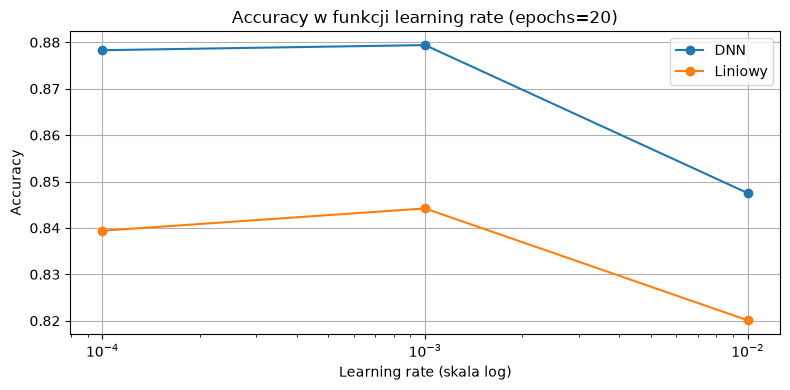

In [41]:
# Zbiorczy wykres accuracy w funkcji learning rate dla obu modeli
# Dane: eksperymenty z epochs=20, zmienny lr
lr_results = summary[summary["Epochs"] == 20].copy()

plt.figure(figsize=(8, 4))
for model_name, group in lr_results.groupby("Model"):
    group_sorted = group.sort_values("Learning rate")
    plt.plot(group_sorted["Learning rate"], group_sorted["Accuracy"],
             marker="o", label=model_name)

plt.xscale("log")
plt.xlabel("Learning rate (skala log)")
plt.ylabel("Accuracy")
plt.title("Accuracy w funkcji learning rate (epochs=20)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Drugi wykres zbiorczy przedstawia charakterystykę accuracy w funkcji epok, czyli jak ilość epok wpływa na `accuracy` przy stałym `learning rate`. Tutaj dla modelu nieliniowego i liniowego wnioski są inne - dla modelu nieliniowego im większa ilość epok tym wskaźnic accuracy jest większy, natomaist dla sieci liniowej różnice są lewdo zauważalne.

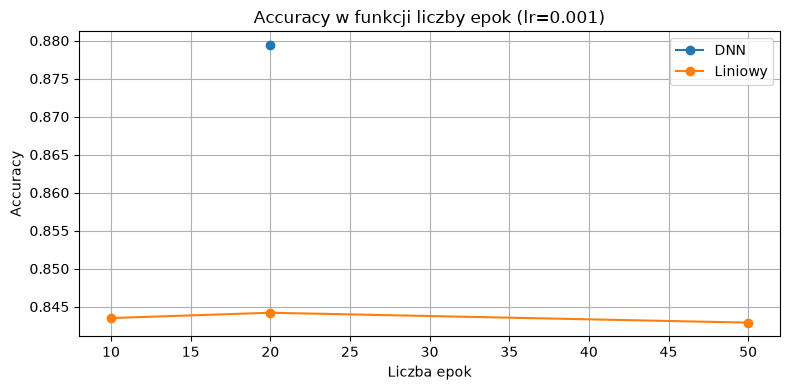

In [42]:
# Zbiorczy wykres accuracy w funkcji liczby epok dla obu modeli
# Dane: eksperymenty z lr=0.001, zmienna liczba epok
epoch_results = summary[summary["Learning rate"] == 0.001].copy()

plt.figure(figsize=(8, 4))
for model_name, group in epoch_results.groupby("Model"):
    group_sorted = group.sort_values("Epochs")
    plt.plot(group_sorted["Epochs"], group_sorted["Accuracy"],
             marker="o", label=model_name)

plt.xlabel("Liczba epok")
plt.ylabel("Accuracy")
plt.title("Accuracy w funkcji liczby epok (lr=0.001)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
# Trening finalnego modelu na podstawie najlepszych parametrów z eksperymentów
best_model = build_dnn_model(lr=0.001)
best_model.fit(
    train_images_normalized, train_labels,
    epochs=50,
    validation_split=0.1,
    verbose=1
)

# Predykcje
y_pred_proba = best_model.predict(test_images_normalized)
y_pred       = np.argmax(y_pred_proba, axis=1)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8203 - loss: 0.5052 - val_accuracy: 0.8533 - val_loss: 0.4016
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8651 - loss: 0.3721 - val_accuracy: 0.8607 - val_loss: 0.3678
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8773 - loss: 0.3343 - val_accuracy: 0.8690 - val_loss: 0.3536
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8854 - loss: 0.3093 - val_accuracy: 0.8658 - val_loss: 0.3592
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8916 - loss: 0.2917 - val_accuracy: 0.8677 - val_loss: 0.3680
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8964 - loss: 0.2758 - val_accuracy: 0.8715 - val_loss: 0.3569
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9015 - loss: 0.2624 - val_accuracy: 0.8748 - val_loss: 0.3611
Epoch 8/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9056 - loss: 0.2511 - 

W tym miejscu w ramach dokładniejszej analizy otrzymanych wyników został utworzony tzw. confusion matrix, czli macierz pomyłek. Po przekątnej widać ile z próbek zostało poprawnie zaklasyfikowanych a na pozostałych polach są widoczne błędne klasyfikacje. Na podstawie tejże macierzy pomyłek widać, że największe problemy w klasyfikacji sprawily głównie trzy klasy: `Shirt`, `Pullover` oraz `Coat`.

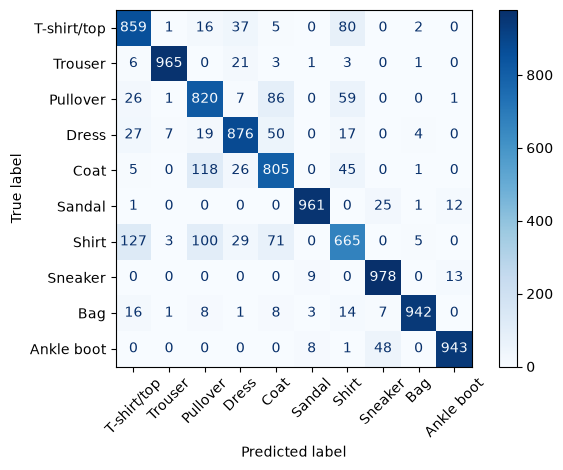

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    test_labels, y_pred,
    display_labels=class_names,
    xticks_rotation=45,
    cmap="Blues"
)
plt.tight_layout()
plt.show()

Poniżej w ramach daleszej analizy zostały pokazane wartości parametrów precision, recall i F1 dla każdej z klas. Jak widać, wartości wszystkich klas oprócz `Shirt` są na ogół dosyć wysokie.

Poszczególne wartości w praktyce oznaczają:
- **Accuracy (Dokładność ogólna)**: określa stosunek poprawnie sklasyfikowanych obrazów do wszystkich próbek w zbiorze testowym. Była to główna metryka monitorowana podczas treningu (funkcja `fit`), pozwalająca ocenić ogólny postęp nauki modeli na przestrzeni epok.
- **Precision (Precyzja)**: określa zdolność modelu do nieoznaczania klasy negatywnej jako pozytywnej (tj. jak duży procent ubrań zaklasyfikowanych do danej kategorii faktycznie do niej należał).
- **Recall (Czułość / Pełność)**: mierzy zdolność modelu do wykrywania wszystkich próbek z danej klasy (tj. jaki procent ubrań z danej kategorii został prawidłowo wykryty).
- **F1-score**- średnia harmoniczna precyzji i czułości, stanowiąca zbalansowany wskaźnik efektywności modelu dla każdej klasy osobno.
- **Confusion Matrix (Macierz pomyłek)**: kluczowe narzędzie analityczne, które pozwoliło na szczegółową identyfikację, z którymi klasami (np. `Shirt`, `Pullover`, `Coat`) modele miały największy problem z powodu ich wizualnego podobieństwa w niskiej rozdzielczości 28×28 pikseli.

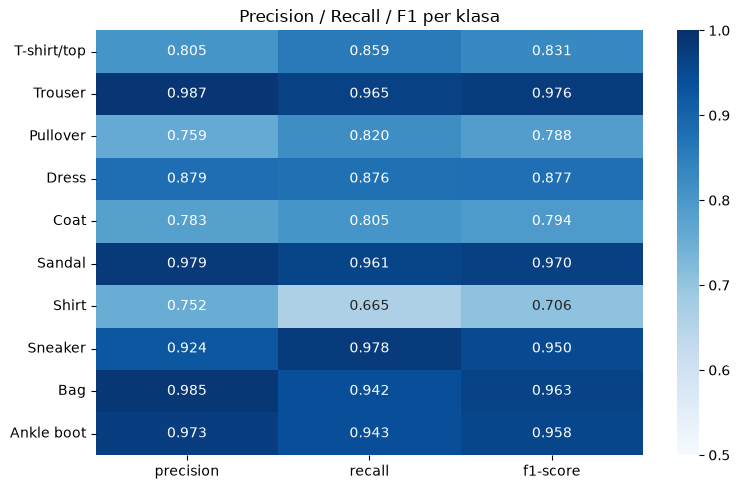

In [46]:
from sklearn.metrics import classification_report

report = classification_report(
    test_labels, y_pred,
    target_names=class_names,
    output_dict=True
)

# Wizualizacja jako heatmapa — czytelniejsza niż surowy tekst
report_df = pd.DataFrame(report).T.iloc[:-3, :3]  # tylko klasy, bez avg
report_df = report_df.astype(float).round(3)

plt.figure(figsize=(8, 5))
sns.heatmap(report_df, annot=True, fmt=".3f", cmap="Blues", vmin=0.5, vmax=1.0)
plt.title("Precision / Recall / F1 per klasa")
plt.tight_layout()
plt.show()

Dla dodatkowej wizualizacji w tym miejscu zostają przedstawione przykładowe obrazy, które zostały poddane błędnej klasyfikacji.

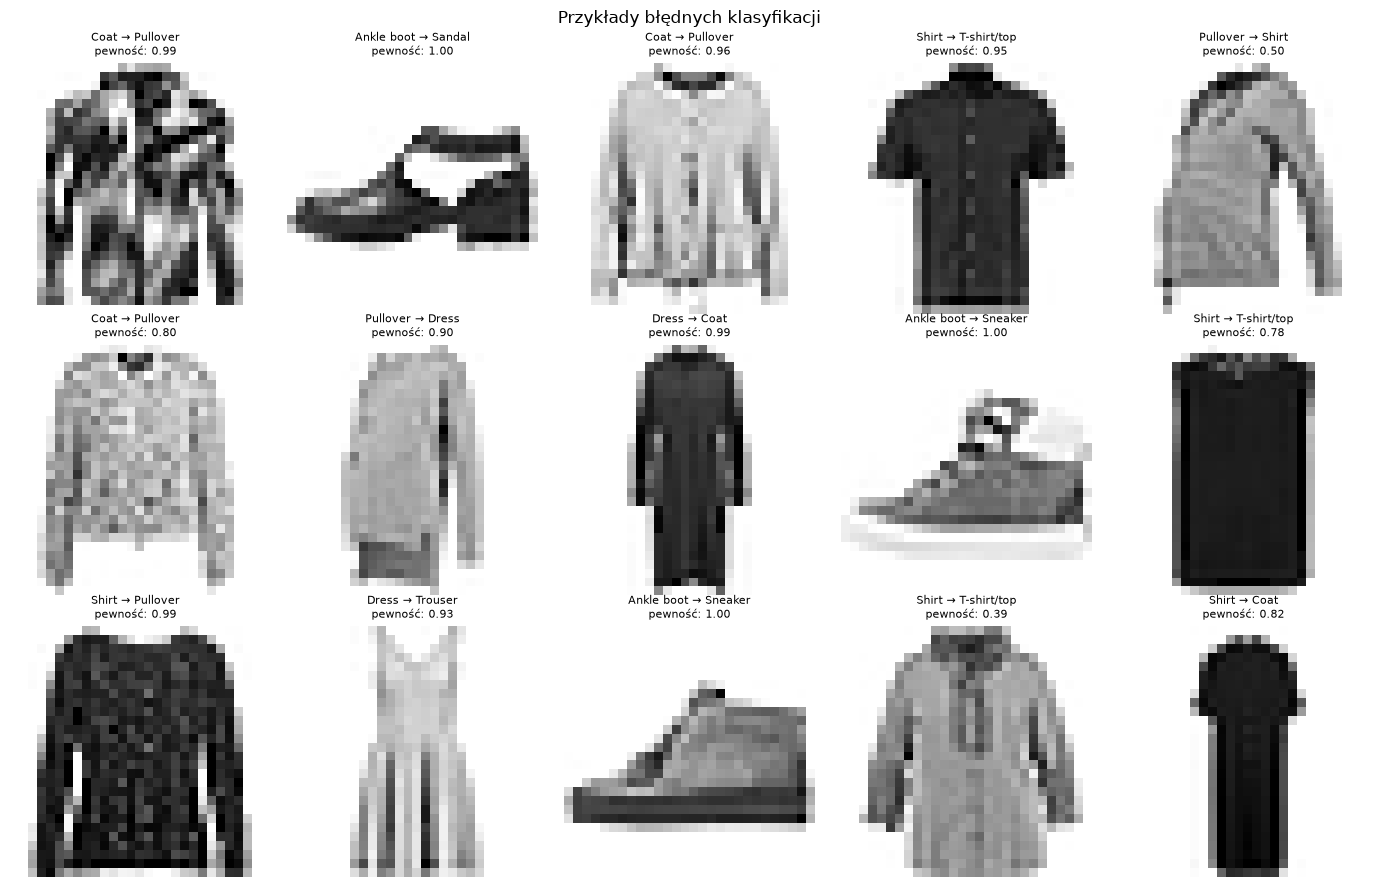

In [47]:
wrong_idx = np.where(y_pred != test_labels)[0]

fig, axes = plt.subplots(3, 5, figsize=(14, 9))
fig.suptitle("Przykłady błędnych klasyfikacji")

for ax, idx in zip(axes.flat, wrong_idx[:15]):
    ax.imshow(test_images_normalized[idx], cmap="binary")
    ax.set_title(
        f"{class_names[test_labels[idx]]} → {class_names[y_pred[idx]]}\n"
        f"pewność: {y_pred_proba[idx, y_pred[idx]]:.2f}",
        fontsize=8
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

Ostatni wykres przedstawia pewność predykcji w formie różnicy wartości `top1` i `top2`. W praktyce oznacza to z jaką "pewnością" model zaklasyfikował daną próbkę do danej klasy. Na wykresie widać, że obie wartości są skośne lewostronnie, co oznacza że model był zarówno pewny poprawnych klasyfikacji jak i tych niepoprawnych.

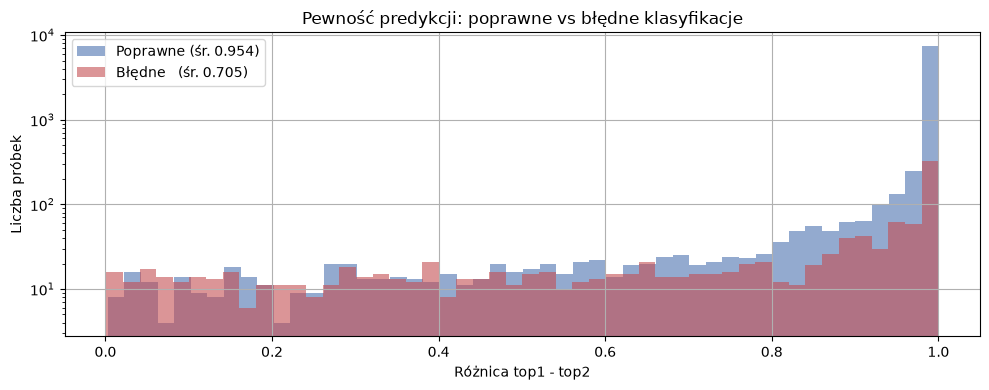

In [48]:
# Różnica między najwyższym a drugim prawdopodobieństwem — miara pewności modelu
sorted_proba = np.sort(y_pred_proba, axis=1)[:, ::-1]
margin = sorted_proba[:, 0] - sorted_proba[:, 1]
correct_mask = (y_pred == test_labels)

plt.figure(figsize=(10, 4))
plt.hist(margin[correct_mask],  bins=50, alpha=0.6, label=f"Poprawne (śr. {margin[correct_mask].mean():.3f})",  color="#4C72B0")
plt.hist(margin[~correct_mask], bins=50, alpha=0.6, label=f"Błędne   (śr. {margin[~correct_mask].mean():.3f})", color="#C44E52")
plt.yscale("log")
plt.xlabel("Różnica top1 - top2")
plt.ylabel("Liczba próbek")
plt.title("Pewność predykcji: poprawne vs błędne klasyfikacje")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Podsumowanie i wnioski

Celem projektu była klasyfikacja obrazów z datasetu Fashion MNIST z wykorzystaniem biblioteki Keras, ze szczególnym naciskiem na analizę liniowej sieci neuronowej oraz jej porównanie z głęboką siecią nieliniową (DNN).

Przeprowadzone eksperymenty wykazały, że dla obu architektur optymalną wartością współczynnika uczenia okazało się `lr`=0.001. Wartość wyższa (`lr`=0.01) prowadziła do niestabilnego treningu i objawów overfittingu widocznych na krzywych funkcji straty - `val_loss` przestawał maleć lub zaczynał rosnąć podczas gdy loss treningowy nadal się obniżał. Wartość niższa (`lr`=0.0001) skutkowała wolniejszą i mniej efektywną konwergencją, co przekładało się na niższe końcowe accuracy przy tej samej liczbie epok.

Wpływ liczby epok. Dla modelu liniowego zwiększanie liczby epok powyżej 20 przynosiło marginalne korzyści - model osiągał swój sufit możliwości stosunkowo szybko, co jest bezpośrednią konsekwencją jego architektury. Brak warstw ukrytych z nieliniową aktywacją ogranicza zdolność modelu do wychwytywania złożonych wzorców w danych, przez co dodatkowe epoki nie wnoszą istotnej poprawy. Model DNN natomiast konsekwentnie poprawiał accuracy wraz ze wzrostem liczby epok, osiągając najlepsze wyniki przy `epochs`=50.

Analiza błędów klasyfikacji. Macierz pomyłek oraz raport precision/recall/F1 ujawniły że najtrudniejszymi klasami do poprawnej klasyfikacji były `Shirt`, `Pullover` oraz `Coat`. Przyczyną jest ich wizualne podobieństwo - wszystkie trzy klasy mają zbliżony obrys sylwetki, podobną strefę kołnierza i długość rękawów, a rozdzielczość 28×28 pikseli nie dostarcza wystarczającej ilości szczegółów do pewnego rozróżnienia. Klasy takie jak `Trouser` i `Bag` były natomiast klasyfikowane niemal bezbłędnie ze względu na unikalny i charakterystyczny kształt.